<a href="https://colab.research.google.com/drive/1A3WVJDT5cFJmWsCoi4b6sf_whx-FuVHh?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## MRI classification on morphometry data

### 1. Introduction

We'll do a fairly conventional morphometry analysis and look for sex-related structural signs in the brain.

The task: build a classifier that tells apart male and female brains from FreeSurfer measures, and along the way see which structures carry the signal. Think of it as an excuse to walk through the whole pipeline - stats, feature selection, multiple comparisons, a linear model - on real data.

Data comes from the Human Connectome Project (HCP-1200): https://db.humanconnectome.org/data/projects/HCP_1200

*By running this you confirm you have personal access to the data and agree to HCP's [data use terms](https://www.humanconnectome.org/study/hcp-young-adult/data-use-terms).*

### 2. Local setup

Use **Python 3.12**. The supplied `requirements.txt` pins the Python packages used by the seminar and includes JupyterLab plus an IPython kernel.

#### macOS or Linux

Open a terminal in the directory containing this notebook and `requirements.txt`, then run:

```bash
python3.12 -m venv .venv
source .venv/bin/activate
python -m pip install --upgrade pip
python -m pip install -r requirements.txt
python -m ipykernel install --user --name morphometry-seminar --display-name "Python (morphometry seminar)"
jupyter lab
```

#### Windows PowerShell

```powershell
py -3.12 -m venv .venv
.\.venv\Scripts\Activate.ps1
python -m pip install --upgrade pip
python -m pip install -r requirements.txt
python -m ipykernel install --user --name morphometry-seminar --display-name "Python (morphometry seminar)"
jupyter lab
```

In JupyterLab, open this notebook and select **Kernel -> Change Kernel -> Python (morphometry seminar)**.

The main packages are:

- `numpy` and `scipy`: numerical and statistical routines;
- `pandas`: loading and manipulating the morphometry table;
- `scikit-learn`: train/test splitting, feature selection, scaling, logistic regression, and metrics;
- `statsmodels`: multiple-testing corrections;
- `gdown`: downloading the seminar CSV from Google Drive;
- `jupyterlab` and `ipykernel`: running the notebook locally.


### 3. Getting the data

The id below points at the FreeSurfer table in the shared folder. 

In [1]:
from pathlib import Path
import gdown

# Store downloaded data beside the notebook instead of using Colab's /content/.
data_dir = Path("data")
data_dir.mkdir(parents=True, exist_ok=True)
data_path = data_dir / "unrestricted_hcp_freesurfer.csv"

if data_path.exists():
    print(f"Using existing file: {data_path.resolve()}")
else:
    file_id = "1OR5i_iePptN1of0LNgwtFVMuKRieJOUX"
    downloaded = gdown.download(id=file_id, output=str(data_path), quiet=False)
    if downloaded is None:
        raise RuntimeError("The data download failed. Check your network connection and file access.")
    print(f"Downloaded to: {data_path.resolve()}")


Downloading...
From: https://drive.google.com/uc?id=1OR5i_iePptN1of0LNgwtFVMuKRieJOUX
To: /workspace/seminar5_neuroml/1_morphometry_classification/data/unrestricted_hcp_freesurfer.csv
100%|██████████| 5.99M/5.99M [00:00<00:00, 10.9MB/s]

Downloaded to: /workspace/seminar5_neuroml/1_morphometry_classification/data/unrestricted_hcp_freesurfer.csv


Load it up.

In [2]:
import pandas as pd

data = pd.read_csv(data_path)


In [3]:
data.head()

,Subject,Gender,Release,FS_InterCranial_Vol,FS_BrainSeg_Vol,FS_BrainSeg_Vol_No_Vent,FS_BrainSeg_Vol_No_Vent_Surf,FS_LCort_GM_Vol,FS_RCort_GM_Vol,FS_TotCort_GM_Vol,...,FS_R_Rostralanteriorcingulate_CurvInd,FS_R_Rostralmiddlefrontal_CurvInd,FS_R_Superiorfrontal_CurvInd,FS_R_Superiorparietal_CurvInd,FS_R_Superiortemporal_CurvInd,FS_R_Supramarginal_CurvInd,FS_R_Frontalpole_CurvInd,FS_R_Temporalpole_CurvInd,FS_R_Transversetemporal_CurvInd,FS_R_Insula_CurvInd
0,100206,M,S900,1.864518e+06,1406924.0,1389007.0,1.386836e+06,304488,305634,610122,...,5.6,34.6,40.1,23.3,15.6,11.9,2.9,3.8,2.8,37.5
1,100307,F,Q1,1.512540e+06,1109710.0,1098854.0,1.097122e+06,240030,243207,483238,...,3.3,29.9,48.8,21.6,18.6,15.0,2.9,5.8,2.0,30.2
2,100408,M,Q3,1.684117e+06,1280171.0,1260943.0,1.259250e+06,260695,265243,525938,...,3.3,25.2,27.5,15.2,13.9,12.3,1.8,7.8,1.9,25.1
3,100610,M,S900,1.816044e+06,1321362.0,1306929.0,1.304569e+06,276506,278002,554508,...,3.0,19.6,20.0,18.6,10.6,10.8,1.2,4.1,1.4,16.6
4,101006,F,S500,1.437868e+06,1053766.0,1038408.0,1.037793e+06,203718,210539,414257,...,2.9,14.7,21.3,13.2,8.7,9.8,1.1,3.0,1.0,18.9


Where does this table come from, if you wanted to make your own? Roughly:

- start from a T1-weighted scan (T2 helps but isn't required),
- get subjects into BIDS or at least plain `.nii`,
- run FreeSurfer 6.0 (the docker image is easiest),
- wait. It's about 5-11 hours per subject on a single core.
- collect the `*.stats` files and flatten them into a table like this one.

So the CSV we loaded in two seconds represents a lot of compute.

### 4. Features and target

935 morphometry columns per subject. Two obvious targets live in this table - sex, and age-over-30 - we'll go with sex.

Binarize the target with .map

In [4]:
X = data[data.columns[3:]]
y = data[data.columns[1]].map({'F': 1, 'M': 0}).astype(int)   # F=1, M=0
X.shape, y.shape

((1113, 935), (1113,))

In [5]:
y.value_counts()

Gender
1    606
0    507
Name: count, dtype: int64

Split before we touch the data with anything that learns. Stratify so the class ratio survives.

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train.shape, X_test.shape

((890, 935), (223, 935))

A quick bit of housekeeping that matters later. Some FreeSurfer columns are identical for every subject (they're constant). They carry zero information and, worse, they blow up the ANOVA F-test - variance-within-group is 0, so you divide by zero and get NaNs. Drop them once here and both the stats and the model use the clean matrix.

In [7]:
nonconstant = X_train.columns[X_train.nunique() > 1]
dropped = X_train.shape[1] - len(nonconstant)
print(f"dropping {dropped} constant columns, {len(nonconstant)} features left")

X_train = X_train[nonconstant]
X_test  = X_test[nonconstant]

dropping 28 constant columns, 907 features left


### 5. Classical analysis first

Before any ML, a few questions worth arguing about in the room:

1. Comparing two groups on each feature - parametric or not? Are these features anywhere near Gaussian?
2. Paired or unpaired? (These are different people, so...)
3. What threshold, and - the interesting one - what do you do about running the test 900 times?

Feature selection with a univariate filter: https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html

We fit it on the training set only.

In [8]:
from sklearn.feature_selection import SelectKBest, f_classif

skb = SelectKBest(score_func=f_classif, k=20)
X_train_new = skb.fit_transform(X_train, y_train)
X_test_new  = skb.transform(X_test)
X_train_new.shape

(890, 20)

In [9]:
selected = X_train.columns[skb.get_support()]
selected

Index(['FS_InterCranial_Vol', 'FS_BrainSeg_Vol', 'FS_BrainSeg_Vol_No_Vent',
       'FS_BrainSeg_Vol_No_Vent_Surf', 'FS_LCort_GM_Vol', 'FS_RCort_GM_Vol',
       'FS_TotCort_GM_Vol', 'FS_SubCort_GM_Vol', 'FS_Total_GM_Vol',
       'FS_SupraTentorial_Vol', 'FS_SupraTentorial_Vol_No_Vent',
       'FS_SupraTentorial_No_Vent_Voxel_Count', 'FS_L_WM_Vol', 'FS_R_WM_Vol',
       'FS_Tot_WM_Vol', 'FS_Mask_Vol', 'FS_L_Amygdala_Vol',
       'FS_L_Cerebellum_Cort_Vol.1', 'FS_L_Amygdala_Vox',
       'FS_R_Insula_GrayVol'],
      dtype='object')

In [10]:
skb.scores_[skb.get_support()]

array([624.89052638, 715.87031636, 697.59564357, 697.99749015,
       552.18591154, 580.69479367, 574.85646631, 540.68340515,
       702.03960831, 648.09901791, 631.82609549, 630.83300091,
       500.2122461 , 501.06413765, 501.73862334, 867.8239351 ,
       504.12177128, 480.25800747, 503.95283951, 496.50180614])

In [11]:
skb.pvalues_[skb.get_support()]

array([7.58137035e-105, 4.00299879e-116, 6.53428991e-114, 5.83802209e-114,
       2.46895787e-095, 4.03744215e-099, 2.37397920e-098, 8.74143489e-094,
       1.88256336e-114, 8.70083806e-108, 9.91728593e-106, 1.32626616e-105,
       3.11422563e-088, 2.37039818e-088, 1.90997598e-088, 1.33643073e-133,
       8.91241839e-089, 1.95355599e-085, 9.40680945e-089, 1.02437796e-087])

What do you know about multiple comparisons?

If one generates many random features and conducts a statistical test on them, one will eventually hit the p-value threshold, even if the features are completely random. Therefore, some corrections are needed.

![graph](https://janhove.github.io/posts/2016-04-01-multiple-comparisons-scenarios/index_files/figure-html/unnamed-chunk-1-1.svg)

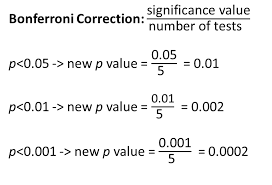

The section above explains *why* we correct. Here we actually do it: run the univariate test across **all** features and correct the p-values with Bonferroni and Benjamini–Hochberg (FDR).

In [12]:
import numpy as np
from statsmodels.stats.multitest import multipletests

F, p = f_classif(X_train, y_train)

_, p_bonf, _, _ = multipletests(p, alpha=0.05, method='bonferroni')
_, p_fdr,  _, _ = multipletests(p, alpha=0.05, method='fdr_bh')

results = pd.DataFrame({
    'feature': X_train.columns,
    'p_raw': p,
    'p_bonferroni': p_bonf,
    'p_fdr_bh': p_fdr,
}).sort_values('p_raw')

results['sig_raw'] = results['p_raw']        < 0.05
results['sig_bonf'] = results['p_bonferroni'] < 0.05
results['sig_fdr'] = results['p_fdr_bh']     < 0.05

print("raw p<0.05:", results['sig_raw'].sum())
print("Bonferroni:", results['sig_bonf'].sum())
print("FDR (BH):", results['sig_fdr'].sum())
results.head(15)

raw p<0.05: 621
Bonferroni: 438
FDR (BH): 601


,feature,p_raw,p_bonferroni,p_fdr_bh,sig_raw,sig_bonf,sig_fdr
15,FS_Mask_Vol,1.336431e-133,1.212143e-130,1.212143e-130,True,True,True
1,FS_BrainSeg_Vol,4.002999e-116,3.630720e-113,1.815360e-113,True,True,True
8,FS_Total_GM_Vol,1.882563e-114,1.707485e-111,5.691617e-112,True,True,True
3,FS_BrainSeg_Vol_No_Vent_Surf,5.838022e-114,5.295086e-111,1.185320e-111,True,True,True
2,FS_BrainSeg_Vol_No_Vent,6.534290e-114,5.926601e-111,1.185320e-111,True,True,True
9,FS_SupraTentorial_Vol,8.700838e-108,7.891660e-105,1.315277e-105,True,True,True
10,FS_SupraTentorial_Vol_No_Vent,9.917286e-106,8.994978e-103,1.284997e-103,True,True,True
11,FS_SupraTentorial_No_Vent_Voxel_Count,1.326266e-105,1.202923e-102,1.503654e-103,True,True,True
0,FS_InterCranial_Vol,7.581370e-105,6.876303e-102,7.640337e-103,True,True,True
5,FS_RCort_GM_Vol,4.037442e-99,3.661960e-96,3.661960e-97,True,True,True


For contrast: one paper that gets multiple comparisons wrong (https://arxiv.org/pdf/1604.05992.pdf) and one that handles it well (https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3056175/).

### 6. Now the model

Logistic regression with built-in cross-validation over the regularization strength. Two things people forget:

- these features are on wildly different scales (a volume in the hundreds of thousands vs a cortical thickness around 2-3 mm), so standardize — and do it *inside* a pipeline so the scaler never sees the test fold,
- because we scaled, the coefficients become comparable afterwards, which is what makes the biomarker step below meaningful.

In [13]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

lr_cv = make_pipeline(
    StandardScaler(),
    LogisticRegressionCV(max_iter=1000, n_jobs=-1, random_state=42)
)
lr_cv.fit(X_train_new, y_train)   # a minute or two

/workspace/seminar5_neuroml/1_morphometry_classification/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/workspace/seminar5_neuroml/1_morphometry_classification/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of LogisticRegre

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregressioncv', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"Cs Cs: int or list of floats, default=10Each of the values in Cs describes the inverse of regularizationstrength. If Cs is as an int, then a grid of Cs values are chosenin a logarithmic scale between 1e-4 and 1e4.Like in support vector machines, smaller values specify strongerregularization.",10
,"l1_ratios l1_ratios: array-like of shape (n_l1_ratios), default=NoneFloats between 0 and 1 passed as Elastic-Net mixing parameter (scaling betweenL1 and L2 penalties). For `l1_ratio = 0` the penalty is an L2 penalty. For`l1_ratio = 1` it is an L1 penalty. For `0 < l1_ratio < 1`, the penalty is acombination of L1 and L2.All the values of the given array-like are tested by cross-validation and theone giving the best prediction score is used... warning:: Certain values of `l1_ratios`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... deprecated:: 1.8 `l1_ratios=None` is deprecated in 1.8 and will raise an error in version 1.10. Default value will change from `None` to `(0.0,)` in version 1.10.",'warn'
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"cv cv: int or cross-validation generator, default=NoneThe default cross-validation generator used is Stratified K-Folds.If an integer is provided, it specifies the number of folds, `n_folds`, used.See the module :mod:`sklearn.model_select

Mean CV accuracy at each regularization strength:

In [14]:
clf = lr_cv.named_steps['logisticregressioncv']
np.mean(clf.scores_[1], axis=0)

array([0.78876404, 0.83033708, 0.84382022, 0.85955056, 0.86966292,
       0.87303371, 0.87191011, 0.86853933, 0.86853933, 0.86966292])

### 7. Which structures is it using?

Since everything was standardized, larger |coef| ≈ more influence on the decision.

In [15]:
coef = clf.coef_.ravel()
biomarkers = (pd.DataFrame({'feature': selected, 'coef': coef})
              .assign(abs_coef=lambda d: d['coef'].abs())
              .sort_values('abs_coef', ascending=False))
biomarkers

,feature,coef,abs_coef
15,FS_Mask_Vol,-3.276498,3.276498
17,FS_L_Cerebellum_Cort_Vol.1,-0.926200,0.926200
1,FS_BrainSeg_Vol,0.838787,0.838787
19,FS_R_Insula_GrayVol,-0.628748,0.628748
8,FS_Total_GM_Vol,0.497384,0.497384
16,FS_L_Amygdala_Vol,-0.441830,0.441830
9,FS_SupraTentorial_Vol,0.432062,0.432062
18,FS_L_Amygdala_Vox,-0.393187,0.393187
2,FS_BrainSeg_Vol_No_Vent,0.323231,0.323231
7,FS_SubCort_GM_Vol,-0.321482,0.321482


Now look at that list honestly. `FS_Mask_Vol`, `FS_BrainSeg_Vol`, total gray matter, intracranial volume... they're nearly all **global size** measures. And male brains are on average larger. So a good chunk of what this "sex classifier" learned is just *head size*, not anything region-specific.

That's the trap in this kind of study. If the goal is genuine sex-specific structure, you usually correct for total intracranial volume (TIV) first - divide each regional volume by TIV, or add TIV as a covariate - and then ask what still separates the groups.

Try it: normalize by intracranial volume and re-run the selection.

In [16]:
# Normalize volume-like features by intracranial volume, then re-select.
tiv = data['FS_InterCranial_Vol']

vol_cols = [c for c in X.columns if 'Vol' in c and c != 'FS_InterCranial_Vol']
X_norm = X.copy()
X_norm[vol_cols] = X_norm[vol_cols].div(tiv, axis=0)

Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(
    X_norm[nonconstant], y, test_size=0.2, stratify=y, random_state=42
)

skb_n = SelectKBest(f_classif, k=20).fit(Xn_tr, yn_tr)
pd.Series(skb_n.scores_[skb_n.get_support()],
          index=Xn_tr.columns[skb_n.get_support()]).sort_values(ascending=False)

FS_SupraTentorial_No_Vent_Voxel_Count    630.833001
FS_InterCranial_Vol                      624.890526
FS_L_Amygdala_Vox                        503.952840
FS_L_Cerebellum_Cort_Vox.1               480.256559
FS_L_Cerebellum_Cort_Vox                 469.022498
FS_R_Amygdala_Vox                        377.107112
FS_R_Inferiorparietal_Area               364.919767
FS_L_Rostralmiddlefrontal_Area           359.354110
FS_L_Rostralmiddlefrontal_NumVert        357.547394
FS_L_Superiorfrontal_Area                357.167123
FS_R_Inferiorparietal_NumVert            352.844588
FS_L_Supramarginal_Area                  349.465768
FS_L_Supramarginal_NumVert               348.005960
FS_R_VentDC_Vox                          346.014882
FS_R_Precentral_Area                     342.535769
FS_R_Superiorfrontal_Area                341.622306
FS_L_Superiorfrontal_NumVert             340.828996
FS_L_VentDC_Vox                          334.482619
FS_R_Fusiform_Area                       333.863373
FS_L_Superio

Compare this ranking to the earlier one. If size-normalization changes who's at the top, that tells you how much of the original signal was really just "bigger brain."

### 8. How good is it, and how would we compare two models?

Report a few metrics rather than accuracy alone - with a near-balanced problem it's fine, but the habit matters. For actually deciding whether model A beats model B, this is a sensible reference: https://arxiv.org/pdf/1806.08295.pdf

In [17]:
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             average_precision_score, roc_auc_score)

y_pred  = lr_cv.predict(X_test_new)
y_proba = lr_cv.predict_proba(X_test_new)[:, 1]

for f in (accuracy_score, balanced_accuracy_score, f1_score):
    print(f.__name__, round(f(y_test, y_pred), 4))
for f in (average_precision_score, roc_auc_score):
    print(f.__name__, round(f(y_test, y_proba), 4))

accuracy_score 0.7848
balanced_accuracy_score 0.7855
f1_score 0.7966
average_precision_score 0.8798
roc_auc_score 0.8725


### What next

- proper hyperparameter search, and a real statistical comparison between two models,
- stability of the selected biomarkers across resamples (do the same features keep showing up?),
- validating them statistically rather than eyeballing coefficients.

Pick one and push on it.